In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed.csv")

print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [3]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')

In [4]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='str')

In [5]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [6]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [7]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['Date'] = trades['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

In [8]:
merged = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [9]:
merged[['Date', 'classification']].head()

,Date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [10]:
profit_by_sentiment = merged.groupby(
    'classification'
)['Closed PnL'].mean().sort_values(ascending=False)

print(profit_by_sentiment)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


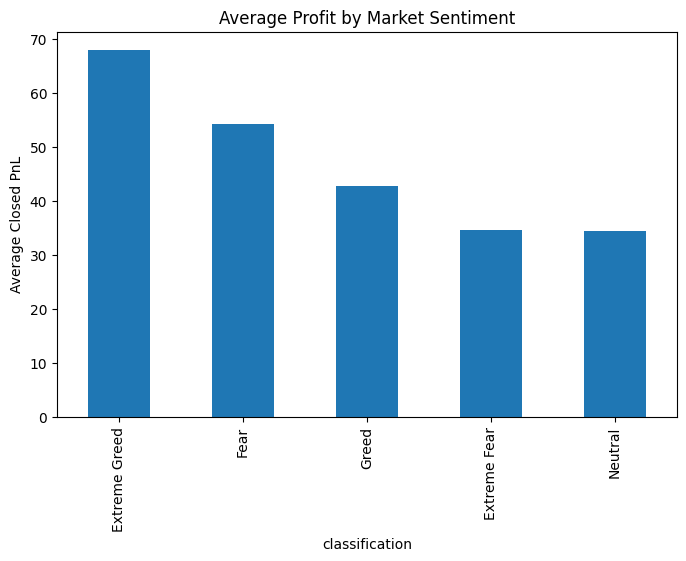

In [11]:
plt.figure(figsize=(8,5))

profit_by_sentiment.plot(kind='bar')

plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

In [12]:
merged['Win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby(
    'classification'
)['Win'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


In [13]:
volume = merged.groupby(
    'classification'
)['Size USD'].sum()

print(volume)

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64


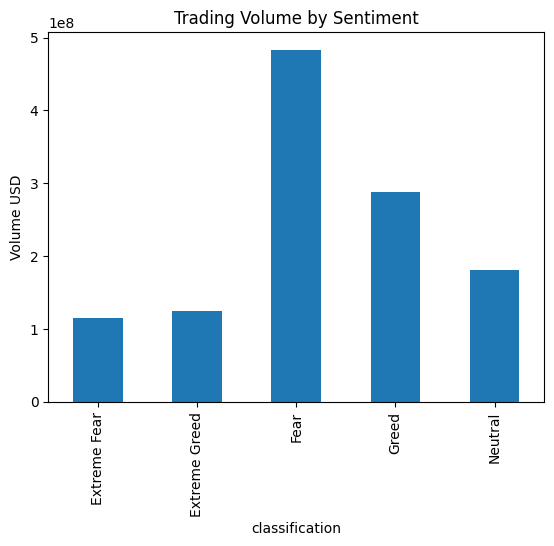

In [14]:
volume.plot(kind='bar')

plt.title('Trading Volume by Sentiment')
plt.ylabel('Volume USD')
plt.show()

In [15]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum()

top_traders.sort_values(
    ascending=False
).head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

In [16]:
side_analysis = merged.groupby(
    ['classification', 'Side']
)['Closed PnL'].mean()

print(side_analysis)

classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64


In [17]:
mapping = {
    'Extreme Fear':1,
    'Fear':2,
    'Greed':3,
    'Extreme Greed':4
}

merged['sentiment_score'] = merged[
    'classification'
].map(mapping)

In [18]:
corr = merged[
    ['sentiment_score',
     'Closed PnL',
     'Size USD',
     'Fee']
].corr()

print(corr)

                 sentiment_score  Closed PnL  Size USD       Fee
sentiment_score         1.000000    0.007356 -0.034493 -0.032906
Closed PnL              0.007356    1.000000  0.123589  0.084020
Size USD               -0.034493    0.123589  1.000000  0.745939
Fee                    -0.032906    0.084020  0.745939  1.000000


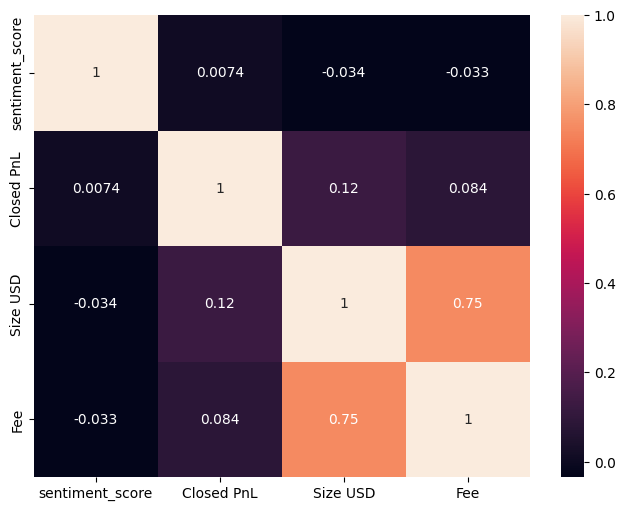

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.show()

In [20]:
merged['classification'].isna().sum()

np.int64(6)

In [21]:
profit_by_sentiment

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [22]:
win_rate

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

In [23]:
top_traders.sort_values(ascending=False).head(10)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64

In [24]:
volume = merged.groupby('classification')['Size USD'].sum()

print(volume)

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64


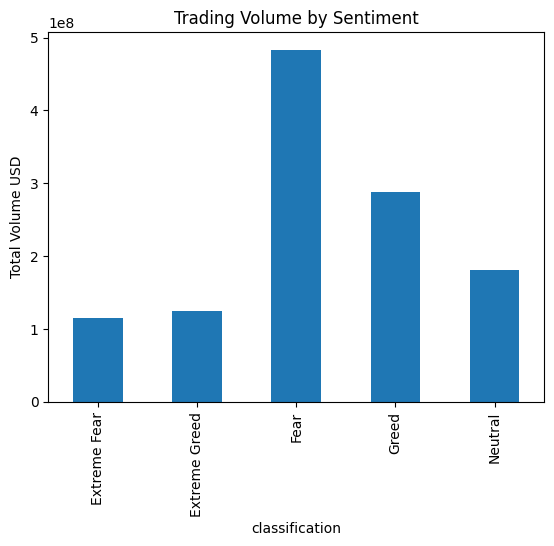

In [25]:
volume.plot(kind='bar')

plt.title('Trading Volume by Sentiment')
plt.ylabel('Total Volume USD')
plt.show()

In [26]:
fee_analysis = merged.groupby('classification')['Fee'].mean()

print(fee_analysis)

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


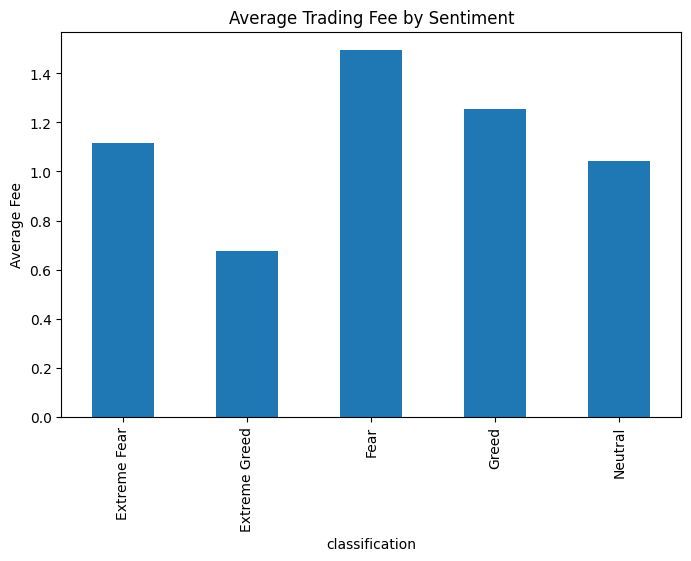

In [27]:
plt.figure(figsize=(8,5))

fee_analysis.plot(kind='bar')

plt.title('Average Trading Fee by Sentiment')
plt.ylabel('Average Fee')

plt.show()

# Trader Behavior vs Bitcoin Market Sentiment

## Objective
Analyze the relationship between Bitcoin market sentiment and trader performance using Hyperliquid trading data and the Fear & Greed Index.

## Key Findings

### 1. Profitability
Average trader profitability was highest during Extreme Greed periods, with an average Closed PnL of 67.89.

### 2. Win Rate
The highest win rate was observed during Extreme Greed (46.49%), while Extreme Fear had the lowest win rate (37.06%).

### 3. Trading Volume
Fear periods generated the highest trading volume, exceeding 483 million USD.

### 4. Top Traders
A small group of traders generated exceptionally high profits, with the top account earning over 2.14 million in total Closed PnL.

### 5. Sentiment Impact
Market sentiment appears to influence both trader activity and profitability, with optimistic markets producing better trading outcomes.

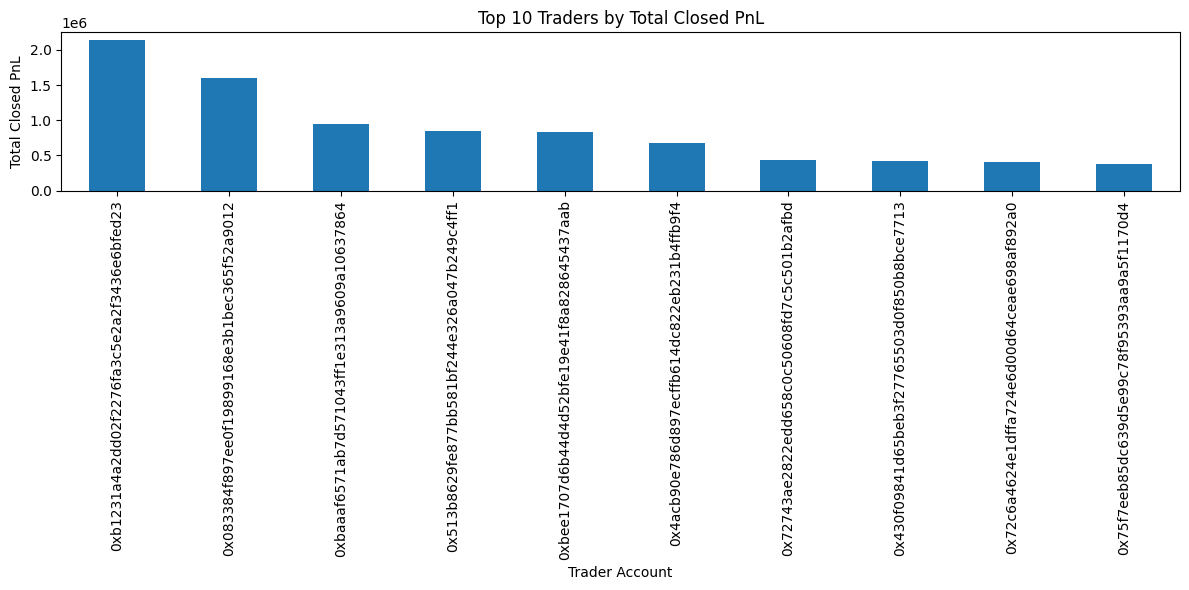

In [28]:
top10 = merged.groupby('Account')['Closed PnL'].sum() \
              .sort_values(ascending=False) \
              .head(10)

plt.figure(figsize=(12,6))
top10.plot(kind='bar')

plt.title('Top 10 Traders by Total Closed PnL')
plt.xlabel('Trader Account')
plt.ylabel('Total Closed PnL')

plt.tight_layout()
plt.show()

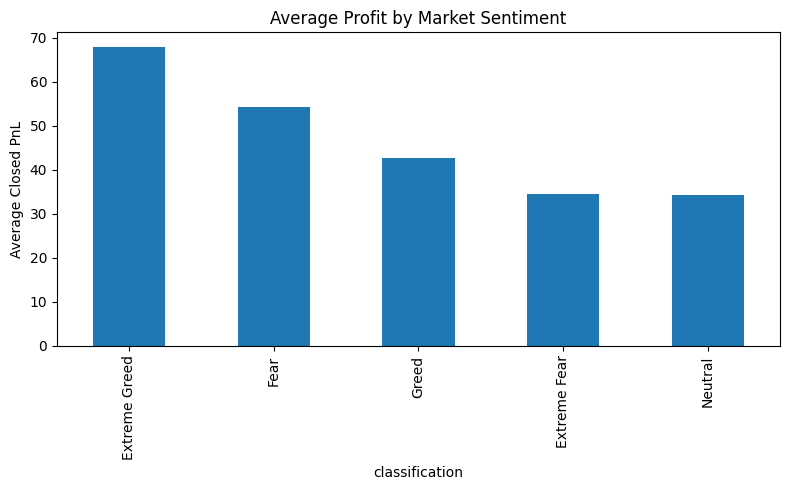

In [29]:
profit_by_sentiment.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.tight_layout()
plt.show()

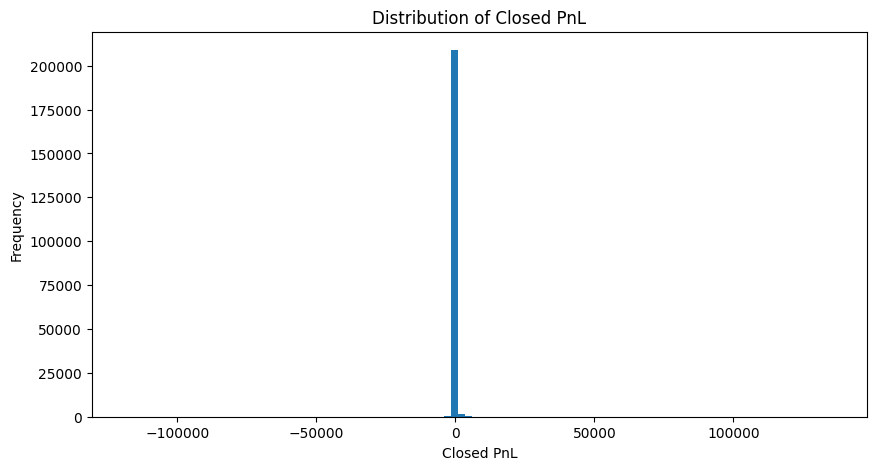

In [30]:
plt.figure(figsize=(10,5))

plt.hist(
    merged['Closed PnL'],
    bins=100
)

plt.title('Distribution of Closed PnL')
plt.xlabel('Closed PnL')
plt.ylabel('Frequency')

plt.show()

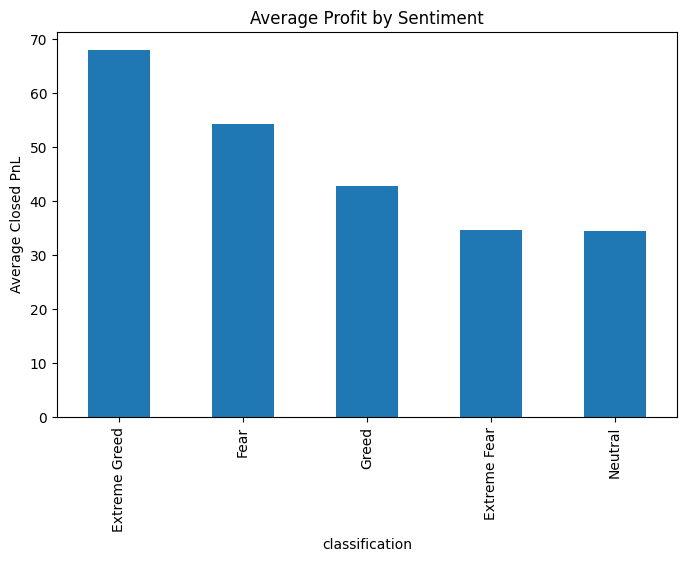

In [31]:
profit_by_sentiment.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Profit by Sentiment')
plt.ylabel('Average Closed PnL')

plt.show()

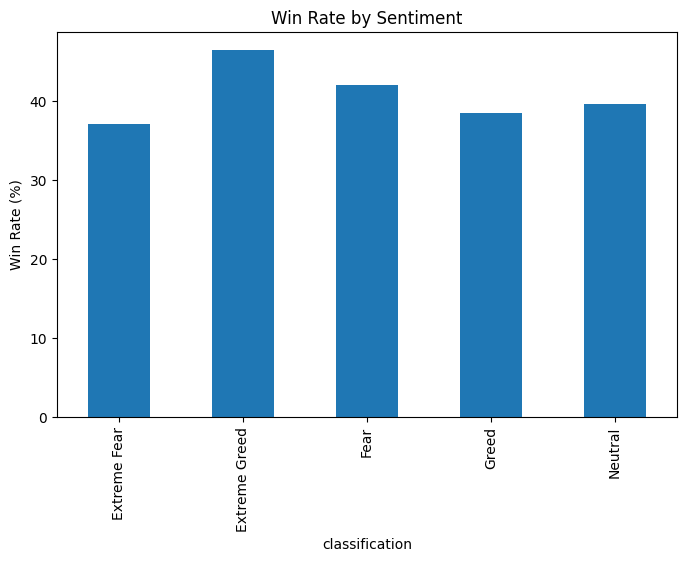

In [32]:
win_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate (%)')

plt.show()

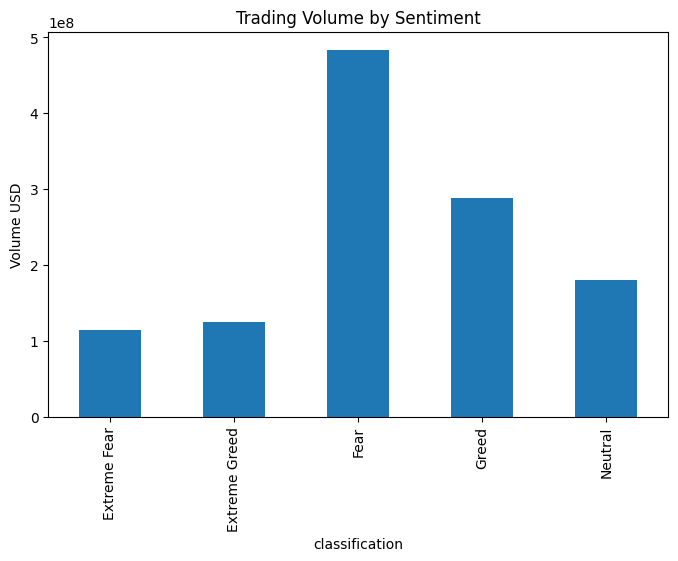

In [33]:
volume.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Trading Volume by Sentiment')
plt.ylabel('Volume USD')

plt.show()

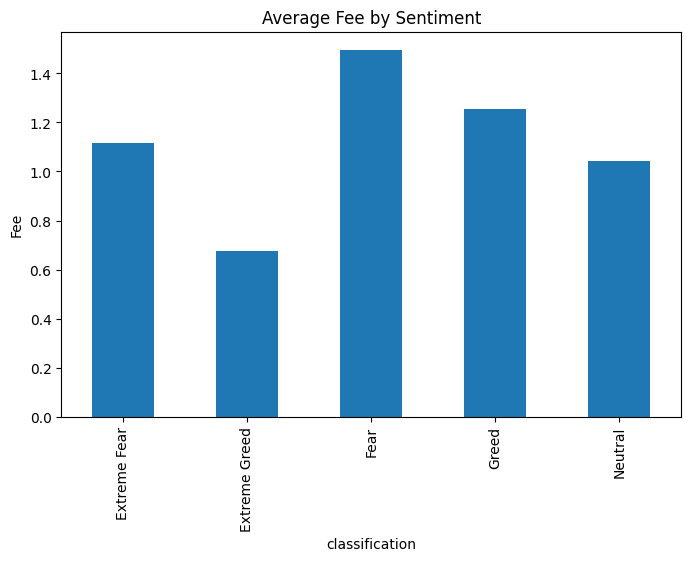

In [34]:
fee_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Average Fee by Sentiment')
plt.ylabel('Fee')

plt.show()

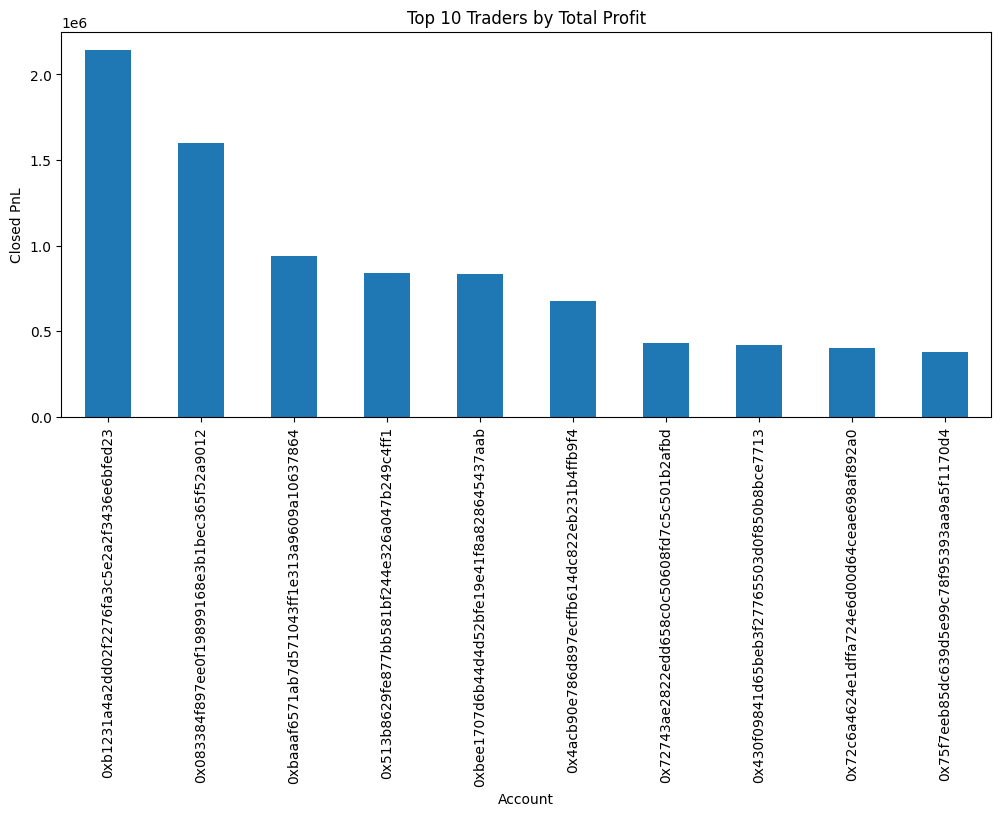

In [35]:
top10 = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,5))

top10.plot(kind='bar')

plt.title('Top 10 Traders by Total Profit')
plt.ylabel('Closed PnL')

plt.show()

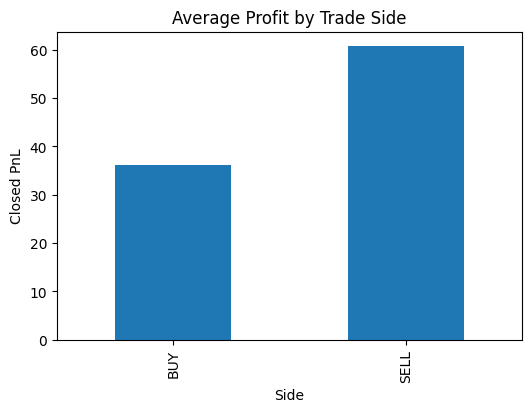

In [36]:
buy_sell = merged.groupby(
    'Side'
)['Closed PnL'].mean()

buy_sell.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Profit by Trade Side')
plt.ylabel('Closed PnL')

plt.show()

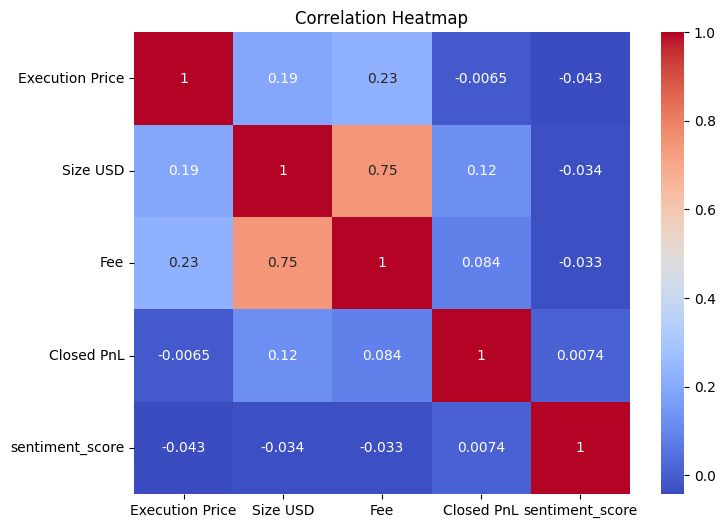

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    merged[
        ['Execution Price',
         'Size USD',
         'Fee',
         'Closed PnL',
         'sentiment_score']
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

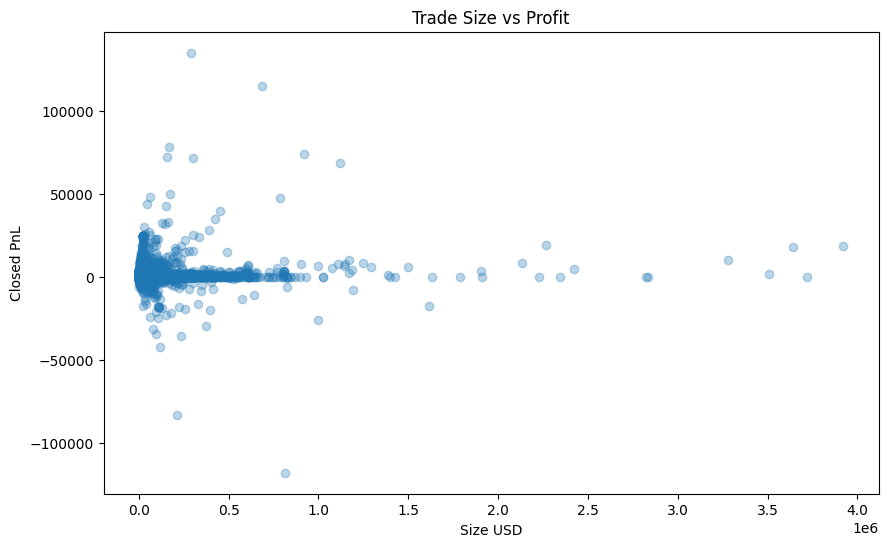

In [38]:
plt.figure(figsize=(10,6))

plt.scatter(
    merged['Size USD'],
    merged['Closed PnL'],
    alpha=0.3
)

plt.title('Trade Size vs Profit')
plt.xlabel('Size USD')
plt.ylabel('Closed PnL')

plt.show()

# Conclusion

This project analyzed the relationship between Bitcoin market sentiment and trader performance using Hyperliquid trading data and the Bitcoin Fear & Greed Index.

## Summary of Findings

### 1. Market Sentiment Influences Profitability
Average trader profitability was highest during Extreme Greed periods, indicating that bullish market conditions create favorable trading opportunities.

### 2. Win Rates Improve During Optimistic Markets
The highest win rate was observed during Extreme Greed, while Extreme Fear produced the lowest success rate.

### 3. Fear Drives Market Activity
Fear periods generated the highest trading volume and average trading fees, suggesting increased trading activity during uncertain market conditions.

### 4. Trading Performance is Highly Concentrated
A relatively small number of trader accounts were responsible for a significant share of total profits, highlighting the impact of trader skill and strategy.

### 5. Asset Selection Matters
Trading activity and profitability varied significantly across cryptocurrencies, demonstrating that asset choice plays an important role in trading outcomes.

## Business Implications

The findings suggest that market sentiment can be a valuable indicator when evaluating trading opportunities and managing risk. Traders appear to perform better during optimistic market conditions, while fearful periods are characterized by higher activity and increased transaction costs.

By combining sentiment indicators with trading metrics, traders and firms can develop more informed trading strategies and improve decision-making processes.

## Future Scope

Future work could include machine learning models to predict trade profitability, deeper behavioral analysis of top-performing traders, and sentiment-driven trading strategy development.

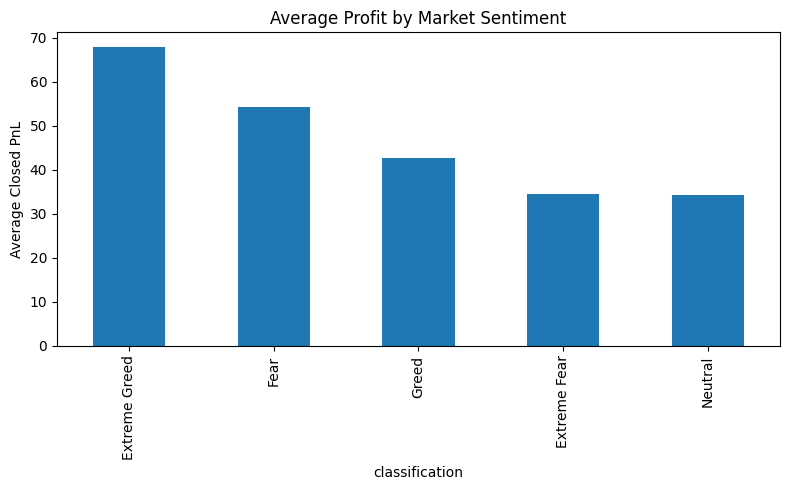

In [39]:
plt.figure(figsize=(8,5))

profit_by_sentiment.plot(kind='bar')

plt.title('Average Profit by Market Sentiment')
plt.ylabel('Average Closed PnL')

plt.tight_layout()
plt.savefig('profit_by_sentiment.png')
plt.show()

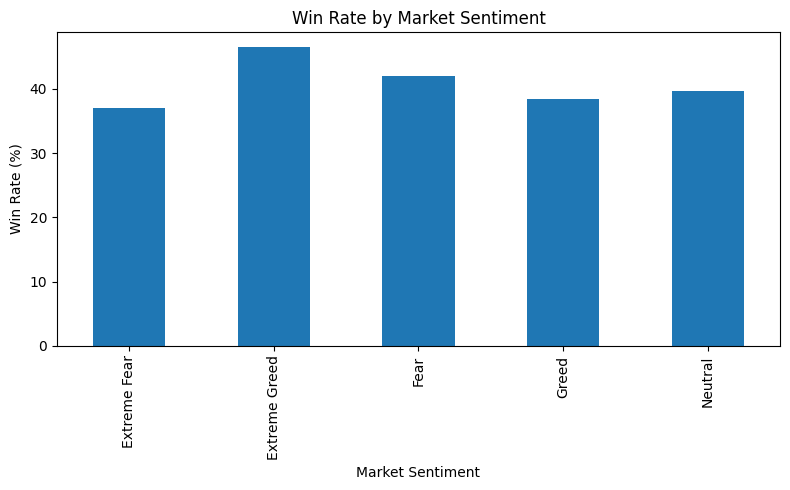

In [40]:
plt.figure(figsize=(8,5))

win_rate.plot(kind='bar')

plt.title('Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')

plt.tight_layout()
plt.savefig('win_rate_by_sentiment.png', dpi=300)

plt.show()

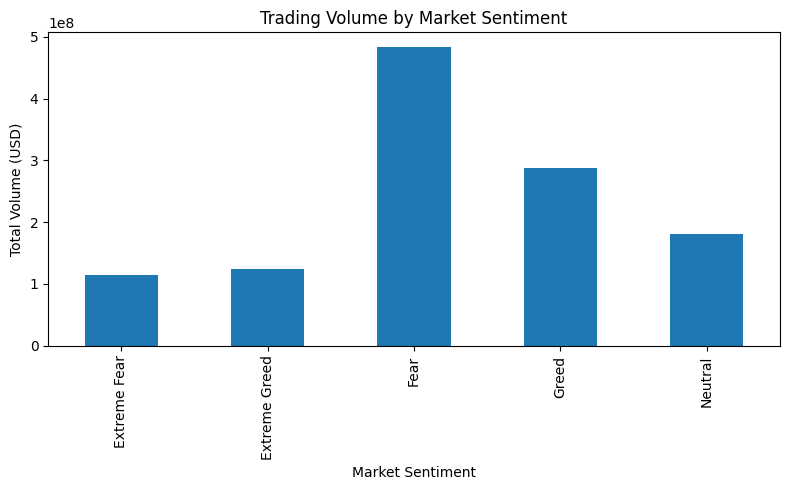

In [41]:
plt.figure(figsize=(8,5))

volume.plot(kind='bar')

plt.title('Trading Volume by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Total Volume (USD)')

plt.tight_layout()
plt.savefig('trading_volume_by_sentiment.png', dpi=300)

plt.show()

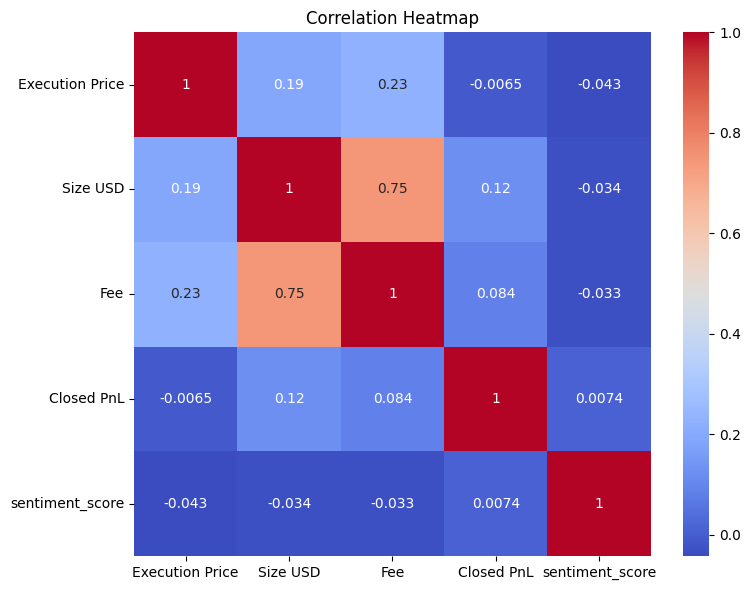

In [42]:
plt.figure(figsize=(8,6))

sns.heatmap(
    merged[
        [
            'Execution Price',
            'Size USD',
            'Fee',
            'Closed PnL',
            'sentiment_score'
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)

plt.show()

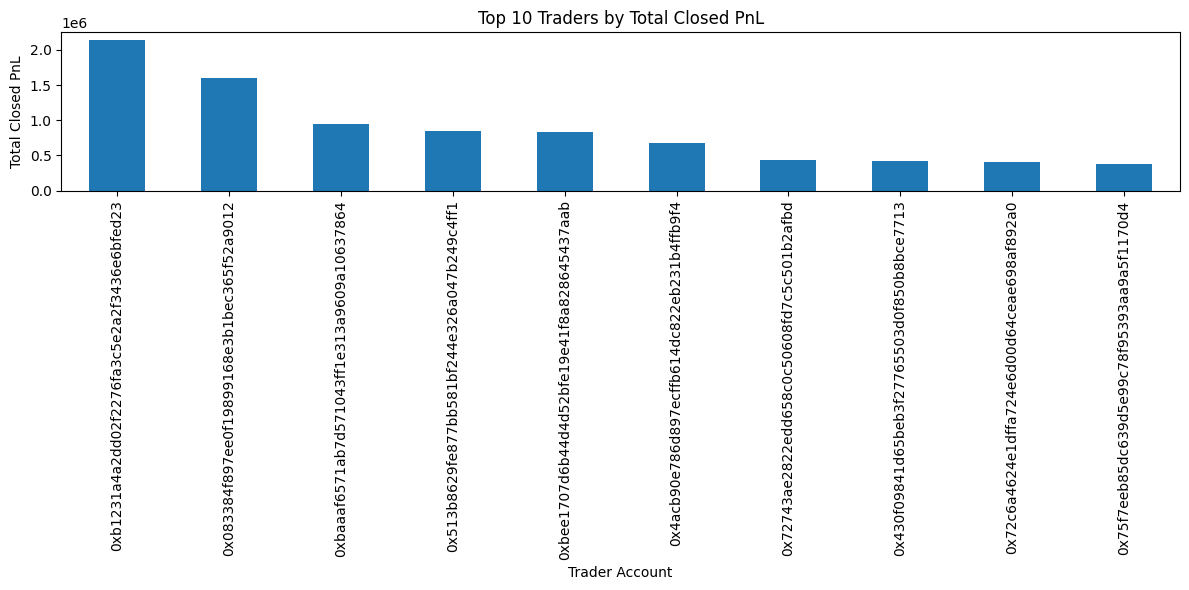

In [43]:
top10 = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top10.plot(kind='bar')

plt.title('Top 10 Traders by Total Closed PnL')
plt.xlabel('Trader Account')
plt.ylabel('Total Closed PnL')

plt.tight_layout()
plt.savefig('top_10_traders.png', dpi=300)

plt.show()